In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("C:/Users/ELCOT/Downloads/load_forecasting_dataset_200_rows-1.csv")

In [5]:
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW)
0,2020-01-01 00:00:00,28.63,65.40,3.82,1.37,0.0,850000.00,1196.58,40.86,Wednesday,0,1,Winter,No,1053.75
1,2020-01-01 00:15:00,29.38,67.86,2.51,2.37,0.0,850025.13,1224.56,40.17,Wednesday,0,1,Winter,Yes,1017.46
2,2020-01-01 00:30:00,27.74,71.32,4.73,0.55,0.0,850050.25,1209.01,40.86,Wednesday,0,1,Winter,No,1060.30
3,2020-01-01 00:45:00,27.97,67.44,2.45,0.44,0.0,850075.38,1215.26,40.43,Wednesday,0,1,Winter,No,1063.90
4,2020-01-01 01:00:00,24.95,72.08,2.44,0.00,0.0,850100.50,1194.23,41.03,Wednesday,1,1,Winter,No,991.22


In [8]:
print(df.columns)

Index(['Timestamp', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)',
       'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'GDP (LKR)',
       'Per Capita Energy Use (kWh)', 'Electricity Price (LKR/kWh)',
       'Day of Week', 'Hour of Day', 'Month', 'Season', 'Public Event',
       'Load Demand (kW)'],
      dtype='str')


In [9]:
df.isnull().sum()

Timestamp                      0
Temperature (°C)               0
Humidity (%)                   0
Wind Speed (m/s)               0
Rainfall (mm)                  0
Solar Irradiance (W/m²)        0
GDP (LKR)                      0
Per Capita Energy Use (kWh)    0
Electricity Price (LKR/kWh)    0
Day of Week                    0
Hour of Day                    0
Month                          0
Season                         0
Public Event                   0
Load Demand (kW)               0
dtype: int64

In [10]:
print(df.duplicated)

<bound method DataFrame.duplicated of                Timestamp  Temperature (°C)  Humidity (%)  Wind Speed (m/s)  \
0    2020-01-01 00:00:00             28.63         65.40              3.82   
1    2020-01-01 00:15:00             29.38         67.86              2.51   
2    2020-01-01 00:30:00             27.74         71.32              4.73   
3    2020-01-01 00:45:00             27.97         67.44              2.45   
4    2020-01-01 01:00:00             24.95         72.08              2.44   
..                   ...               ...           ...               ...   
195  2020-01-03 00:45:00             27.47         67.32              3.05   
196  2020-01-03 01:00:00             27.76         67.92              4.39   
197  2020-01-03 01:15:00             26.90         74.23              4.47   
198  2020-01-03 01:30:00             26.88         72.92              4.43   
199  2020-01-03 01:45:00             25.32         65.83              3.25   

     Rainfall (mm)  Solar

In [11]:
pd.to_datetime(df["Timestamp"])

0     2020-01-01 00:00:00
1     2020-01-01 00:15:00
2     2020-01-01 00:30:00
3     2020-01-01 00:45:00
4     2020-01-01 01:00:00
              ...        
195   2020-01-03 00:45:00
196   2020-01-03 01:00:00
197   2020-01-03 01:15:00
198   2020-01-03 01:30:00
199   2020-01-03 01:45:00
Name: Timestamp, Length: 200, dtype: datetime64[us]

In [12]:
df["Date"]=pd.to_datetime(df["Timestamp"],errors="coerce")

In [13]:
df.head()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date
0,2020-01-01 00:00:00,28.63,65.40,3.82,1.37,0.0,850000.00,1196.58,40.86,Wednesday,0,1,Winter,No,1053.75,2020-01-01 00:00:00
1,2020-01-01 00:15:00,29.38,67.86,2.51,2.37,0.0,850025.13,1224.56,40.17,Wednesday,0,1,Winter,Yes,1017.46,2020-01-01 00:15:00
2,2020-01-01 00:30:00,27.74,71.32,4.73,0.55,0.0,850050.25,1209.01,40.86,Wednesday,0,1,Winter,No,1060.30,2020-01-01 00:30:00
3,2020-01-01 00:45:00,27.97,67.44,2.45,0.44,0.0,850075.38,1215.26,40.43,Wednesday,0,1,Winter,No,1063.90,2020-01-01 00:45:00
4,2020-01-01 01:00:00,24.95,72.08,2.44,0.00,0.0,850100.50,1194.23,41.03,Wednesday,1,1,Winter,No,991.22,2020-01-01 01:00:00


Text(0.5, 1.0, 'Temperature VS Humidity')

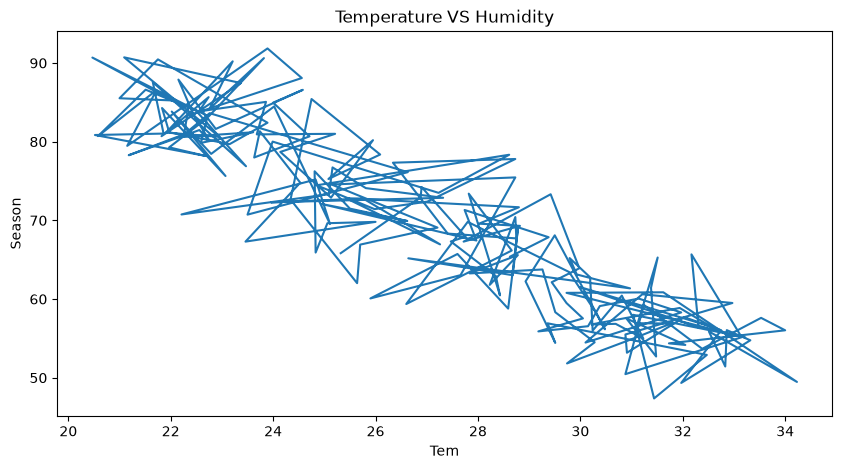

In [19]:
plt.figure(figsize=(10,5))
plt.plot(df['Temperature (°C)'],df['Humidity (%)'])

plt.xlabel("Tem")
plt.ylabel("Season")
plt.title("Temperature VS Humidity")

In [23]:
df["Average"]=df["Wind Speed (m/s)"].rolling(window=5).mean()
df.tail()

,Timestamp,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Date,Average
195,2020-01-03 00:45:00,27.47,67.32,3.05,0.00,0.0,854899.50,1199.76,40.81,Friday,0,1,Winter,No,1018.02,2020-01-03 00:45:00,2.658
196,2020-01-03 01:00:00,27.76,67.92,4.39,0.00,0.0,854924.62,1200.69,39.85,Friday,1,1,Winter,Yes,1056.08,2020-01-03 01:00:00,3.196
197,2020-01-03 01:15:00,26.90,74.23,4.47,0.38,0.0,854949.75,1197.25,40.15,Friday,1,1,Winter,No,1030.52,2020-01-03 01:15:00,3.328
198,2020-01-03 01:30:00,26.88,72.92,4.43,0.14,0.0,854974.87,1211.09,41.09,Friday,1,1,Winter,No,1041.41,2020-01-03 01:30:00,3.480
199,2020-01-03 01:45:00,25.32,65.83,3.25,0.14,0.0,855000.00,1206.50,40.65,Friday,1,1,Winter,No,1039.37,2020-01-03 01:45:00,3.918


In [24]:
for i in range (1,11):
    value1=df["Wind Speed (m/s)"].iloc[i]
    value2=df["Wind Speed (m/s)"].iloc[-i]
    if value2 > value1:
        print("Increasing Trend")
    elif value2 < value1:
        print("Decreasing Trend")
    else:
        print("Stable Trend")

Increasing Trend
Decreasing Trend
Increasing Trend
Increasing Trend
Decreasing Trend
Decreasing Trend
Decreasing Trend
Increasing Trend
Decreasing Trend
Increasing Trend
